<a href="https://colab.research.google.com/github/rohleet/darkknight/blob/main/model_training_and_evaluation/lightgbm_url_detection_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import lightgbm as lgb
import numpy as np
from sklearn.metrics import classification_report
import pandas as pd
import tldextract

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
dataset = pd.read_csv('/content/drive/MyDrive/dataset/engineered_dataset.csv')

In [46]:
import tldextract

def get_domain(url):
    try:
        return tldextract.extract(url).registered_domain
    except Exception:
        return None

dataset["domain"] = dataset["url"].apply(get_domain)

X = dataset.drop(columns=["url", "type", "domain","has_https"])
y = dataset["type"]

/tmp/ipykernel_4713/3723368827.py:5: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
  return tldextract.extract(url).registered_domain


In [47]:
from sklearn.model_selection import GroupShuffleSplit

groups = dataset["domain"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_val_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train_val = X.iloc[train_val_idx]
X_test = X.iloc[test_idx]

y_train_val = y.iloc[train_val_idx]
y_test = y.iloc[test_idx]

groups_train_val = groups.iloc[train_val_idx]

gss2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, val_idx = next(
    gss2.split(X_train_val, y_train_val, groups=groups_train_val)
)

X_train = X_train_val.iloc[train_idx]
X_val = X_train_val.iloc[val_idx]

y_train = y_train_val.iloc[train_idx]
y_val = y_train_val.iloc[val_idx]

In [48]:
model = lgb.LGBMClassifier (
    objective='binary',
    boosting_type =  'gbdt',
    class_weight = 'balanced',
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    num_leaves=31,
    colsample_bytree=0.8,
    random_state=42
)

In [49]:
print("--- Dataset Diagnostics ---")
print(f"Shape of X: {X.shape}")

non_numeric_cols = X.select_dtypes(exclude=['number', 'bool']).columns.tolist()
print(f"Non-numeric columns left in X: {len(non_numeric_cols)}")
if non_numeric_cols:
    print(f"⚠️ First 5 problematic columns: {non_numeric_cols[:5]}")

constant_cols = [col for col in X.columns if X[col].nunique() <= 1]
print(f"Constant columns (zero variance) dropped by LightGBM: {len(constant_cols)}")

--- Dataset Diagnostics ---
Shape of X: (450176, 52)
Non-numeric columns left in X: 0
Constant columns (zero variance) dropped by LightGBM: 0


In [50]:
model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=True),
        lgb.log_evaluation(period=1)
    ]
)

[LightGBM] [Info] Number of positive: 59417, number of negative: 195530
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.077164 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3129
[LightGBM] [Info] Number of data points in the train set: 254947, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[1]	valid_0's binary_logloss: 0.625841
Training until validation scores don't improve for 30 rounds
[2]	valid_0's binary_logloss: 0.559472
[3]	valid_0's binary_logloss: 0.503307
[4]	valid_0's binary_logloss: 0.455786
[5]	valid_0's binary_logloss: 0.419926
[6]	valid_0's binary_logloss: 0.398722
[7]	valid_0's binary_logloss: 0.365287
[8]	valid_0's binary_logloss: 0.341026
[9]	valid_0's binary_logloss: 0.318176
[10]	valid_0's binary_logloss:

LGBMClassifier(class_weight='balanced', colsample_bytree=0.8, max_depth=6,
               n_estimators=300, objective='binary', random_state=42)

In [51]:
predictions = model.predict(X_test)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

  legitimate       0.99      0.98      0.99     74775
    phishing       0.95      0.96      0.95     24415

    accuracy                           0.98     99190
   macro avg       0.97      0.97      0.97     99190
weighted avg       0.98      0.98      0.98     99190



In [52]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance.head(20))

path_length                 724
hostname_entropy            579
letter_ratio                555
domain_entropy              542
url_length                  530
hostname_length             519
domain_length               452
letter_count                383
subdomain_entropy           348
hyphen_count                331
special_char_count          325
digit_count                 316
tld_length                  315
digit_ratio                 299
slash_count                 299
dot_count                   288
subdomain_length            237
subdomain_count             213
path_depth                  199
suspicious_keyword_count    185
dtype: int32


In [55]:
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np

results = []

y_binary = pd.Series(y).map({
    'legitimate': 0,
    'phishing': 1
})

if y_binary.isna().any():
    y_binary = pd.to_numeric(y, errors='coerce')

for col in X.columns:
    try:
        feature = pd.to_numeric(X[col], errors='coerce')

        mask = feature.notna() & np.isfinite(feature) & y_binary.notna()

        feature_clean = feature[mask]
        y_clean = y_binary[mask]

        if feature_clean.nunique() < 2:
            continue

        auc = roc_auc_score(y_clean, feature_clean)

        auc = max(auc, 1 - auc)

        results.append({
            "feature": col,
            "auc": auc
        })

    except Exception as e:
        print(f"Skipped {col}: {e}")

results_df = pd.DataFrame(results).sort_values(
    by="auc",
    ascending=False
).reset_index(drop=True)

print("\n=== UNIVARIATE FEATURE AUC ===\n")
print(results_df.to_string(index=False))

print("\n=== FEATURES WITH AUC >= 0.80 ===\n")
print(
    results_df[results_df["auc"] >= 0.80]
    .to_string(index=False)
)


=== UNIVARIATE FEATURE AUC ===

                 feature      auc
         subdomain_count 0.856146
        subdomain_length 0.785683
suspicious_keyword_count 0.646492
               dot_count 0.617032
         hostname_length 0.602230
           domain_length 0.598604
             slash_count 0.581841
          domain_entropy 0.578184
            hyphen_count 0.571217
     hostname_has_digits 0.565640
              path_depth 0.564428
      special_char_count 0.563793
           login_keyword 0.554657
             digit_ratio 0.551308
              tld_length 0.549558
            letter_ratio 0.542321
        underscore_count 0.542072
            letter_count 0.540800
             digit_count 0.538527
              url_length 0.533825
     hostname_has_hyphen 0.533205
            query_length 0.532363
     question_mark_count 0.529755
            equals_count 0.527212
             path_length 0.524674
         ampersand_count 0.523635
        hostname_entropy 0.522139
        securit

In [56]:
print(
    dataset.groupby("type")["subdomain_count"]
    .describe()
)

               count      mean       std  min  25%  50%  75%   max
type                                                              
legitimate  345738.0  1.256819  0.489324  0.0  1.0  1.0  1.0   8.0
phishing    104438.0  0.392980  0.731630  0.0  0.0  0.0  1.0  19.0


In [57]:
print(
    pd.crosstab(
        pd.cut(
            dataset["subdomain_count"],
            bins=[-1, 0, 1, 2, 3, 5, 10, 100],
            labels=["0", "1", "2", "3", "4-5", "6-10", "11+"]
        ),
        dataset["type"],
        normalize="index"
    )
)

type             legitimate  phishing
subdomain_count                      
0                  0.004766  0.995234
1                  0.894456  0.105544
2                  0.972032  0.027968
3                  0.909526  0.090474
4-5                0.657758  0.342242
6-10               0.019802  0.980198
11+                0.000000  1.000000


In [58]:
print(
    dataset[dataset["subdomain_count"] == 0][
        ["url", "type", "subdomain_count"]
    ].sample(30, random_state=42).to_string(index=False)
)

                                                                                                                                                                                                                                          url       type  subdomain_count
                                                                                                                                                                                     http://ethoscondominios.com.br/fonts/b/www.bb.com.br/bb/   phishing                0
                                                                                                                                                                                                     http://109.120.142.156/loader2/gate.php?   phishing                0
                                                                                                                                                                                                          

In [59]:
print(
    dataset[dataset["subdomain_count"] >= 6][
        ["url", "type", "subdomain_count"]
    ].sample(30, random_state=42).to_string(index=False)
)

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             url     type  subdomain_count
                                                                                                                                                                                                                             

In [60]:
import tldextract

samples = dataset.sample(20, random_state=42)

for url in samples["url"]:
    e = tldextract.extract(url)

    print(f"\nURL: {url}")
    print(f"subdomain : {e.subdomain}")
    print(f"domain    : {e.domain}")
    print(f"suffix    : {e.suffix}")


URL: http://centralassociatesltd.com/richieeee/index.php
subdomain : 
domain    : centralassociatesltd
suffix    : com

URL: https://www.sbsmnlaw.com/attorney-profiles/
subdomain : www
domain    : sbsmnlaw
suffix    : com

URL: https://www.encyclopedia.com/video/dr_g23qi9hg-che-guevara-song-hasta-siempre.aspx
subdomain : www
domain    : encyclopedia
suffix    : com

URL: https://www.californiabeat.org/2010/08/02/the-end-of-an-era-farewell-to-the-transbay-terminal
subdomain : www
domain    : californiabeat
suffix    : org

URL: https://www.ccdr.org/joan_p_kealiinohomoku.html
subdomain : www
domain    : ccdr
suffix    : org

URL: https://www.myspace.com/vylan
subdomain : www
domain    : myspace
suffix    : com

URL: http://xjbctcky.com/images/?app=com-d3&amp;us.battle.net/login/enhttp=
subdomain : 
domain    : xjbctcky
suffix    : com

URL: https://www.en.wikipedia.org/wiki/Place_du_Portage
subdomain : www.en
domain    : wikipedia
suffix    : org

URL: https://www.stlouis.about.com/b/20

In [45]:
print(pd.crosstab(
    dataset["has_https"],
    dataset["type"],
    normalize="columns"
))

type       legitimate  phishing
has_https                      
0            0.000104  0.937925
1            0.999896  0.062075


In [27]:
print("Total URLs:", len(dataset))
print("Unique URLs:", dataset["url"].nunique())
print("Duplicate URLs:", dataset["url"].duplicated().sum())

Total URLs: 450176
Unique URLs: 450176
Duplicate URLs: 0


In [29]:
train_urls = set(X_train.index)
val_urls = set(X_val.index)
test_urls = set(X_test.index)

print("Train/Test index overlap:", len(train_urls & test_urls))
print("Train/Val index overlap:", len(train_urls & val_urls))
print("Val/Test index overlap:", len(val_urls & test_urls))

Train/Test index overlap: 0
Train/Val index overlap: 0
Val/Test index overlap: 0


In [30]:
train_url_values = set(dataset.loc[X_train.index, "url"])
val_url_values   = set(dataset.loc[X_val.index, "url"])
test_url_values  = set(dataset.loc[X_test.index, "url"])

print("Train/Test duplicate URLs:",
      len(train_url_values & test_url_values))

print("Train/Val duplicate URLs:",
      len(train_url_values & val_url_values))

print("Val/Test duplicate URLs:",
      len(val_url_values & test_url_values))

Train/Test duplicate URLs: 0
Train/Val duplicate URLs: 0
Val/Test duplicate URLs: 0


In [31]:
def get_domain(url):
    try:
        ext = tldextract.extract(url)
        return ext.registered_domain
    except:
        return None

dataset["domain"] = dataset["url"].apply(get_domain)

train_domains = set(dataset.loc[X_train.index, "domain"].dropna())
val_domains   = set(dataset.loc[X_val.index, "domain"].dropna())
test_domains  = set(dataset.loc[X_test.index, "domain"].dropna())

print("Train/Test shared domains:",
      len(train_domains & test_domains))

print("Train/Val shared domains:",
      len(train_domains & val_domains))

print("Val/Test shared domains:",
      len(val_domains & test_domains))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.4/106.4 kB 6.8 MB/s eta 0:00:00


/tmp/ipykernel_4713/2652271263.py:8: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
  return ext.registered_domain


Train/Test shared domains: 16982
Train/Val shared domains: 17037
Val/Test shared domains: 10406


In [61]:
from sklearn.metrics import accuracy_score, roc_auc_score

train_pred = model.predict(X_train)
val_pred   = model.predict(X_val)
test_pred  = model.predict(X_test)

print("Train accuracy:", accuracy_score(y_train, train_pred))
print("Validation accuracy:", accuracy_score(y_val, val_pred))
print("Test accuracy:", accuracy_score(y_test, test_pred))

Train accuracy: 0.9846791686115154
Validation accuracy: 0.9786961546871583
Test accuracy: 0.9775683032563767


In [62]:
import joblib
import os

os.makedirs("/content/drive/MyDrive/dark_knight_model", exist_ok=True)

joblib.dump(
    model,
    "/content/drive/MyDrive/dark_knight_model/dark_knight_lgbm.pkl"
)

joblib.dump(
    list(X.columns),
    "/content/drive/MyDrive/dark_knight_model/features.pkl"
)

print("Model and feature list saved successfully.")

Model and feature list saved successfully.


In [63]:
import os
import json

save_dir = "/content/drive/MyDrive/dark_knight_model"
os.makedirs(save_dir, exist_ok=True)

evaluation = {
    "results": {
        "train_accuracy": float(accuracy_score(y_train, train_pred)),
        "validation_accuracy": float(accuracy_score(y_val, val_pred)),
        "test_accuracy": float(accuracy_score(y_test, test_pred)),
        "test_classification_report": classification_report(
            y_test, test_pred, output_dict=True
        )
    },

    "model": {
        "algorithm": "LightGBM LGBMClassifier",
        "objective": "binary",
        "boosting_type": "gbdt",
        "class_weight": "balanced",
        "n_estimators": 300,
        "learning_rate": 0.1,
        "max_depth": 6,
        "num_leaves": 31,
        "colsample_bytree": 0.8,
        "random_state": 42,
        "early_stopping": 30
    },

    "dataset": {
        "rows": len(dataset),
        "original_feature_count": 53,
        "final_model_feature_count": len(X.columns),
        "removed_features": [
            "url",
            "type",
            "domain",
            "has_https"
        ]
    },

    "data_split": {
        "method": "GroupShuffleSplit",
        "grouping_variable": "registered_domain",
        "test_size": 0.20,
        "validation_size_from_train_validation": 0.25,
        "random_state": 42,
        "purpose": (
            "Prevent URLs from the same registered domain from "
            "appearing across training, validation and test sets."
        )
    },

    "overfitting_investigation": {
        "initial_problem": (
            "A random row-based split allowed the same domains to appear "
            "in multiple splits, creating a risk of overly optimistic "
            "evaluation because URLs from the same domain can share "
            "strong structural characteristics."
        ),

        "random_split_domain_overlap": {
            "train_test_shared_domains": 16982,
            "train_validation_shared_domains": 17037,
            "validation_test_shared_domains": 10406
        },

        "solution": (
            "Replaced the random row-based split with GroupShuffleSplit "
            "using registered_domain as the grouping variable."
        ),

        "result": (
            "Training, validation and test sets were separated by "
            "registered domain, reducing domain-level leakage and making "
            "the test evaluation more representative of performance on "
            "previously unseen domains."
        ),

        "train_validation_test_accuracy_gap": {
            "train_to_validation": float(
                accuracy_score(y_train, train_pred)
                - accuracy_score(y_val, val_pred)
            ),
            "train_to_test": float(
                accuracy_score(y_train, train_pred)
                - accuracy_score(y_test, test_pred)
            )
        },

        "interpretation": (
            "The relatively small train-validation-test accuracy gap "
            "does not indicate severe overfitting under the current "
            "domain-disjoint evaluation setup."
        )
    },

    "duplicate_and_leakage_checks": {
        "duplicate_urls": 0,
        "exact_url_overlap_across_splits": 0,
        "row_index_overlap_across_splits": 0,
        "domain_grouping": "registered_domain",
        "purpose": (
            "Verify that identical URLs or overlapping rows were not "
            "responsible for inflated evaluation results."
        )
    },

    "dataset_bias_investigation": {
        "feature": "has_https",
        "initial_univariate_auc": 0.9689,
        "finding": (
            "HTTPS usage showed an unusually strong relationship with "
            "the dataset labels. Legitimate URLs were overwhelmingly "
            "HTTPS while phishing URLs were predominantly HTTP."
        ),
        "decision": (
            "Removed has_https from the final model because the observed "
            "relationship was considered a strong dataset/source bias "
            "and could reduce real-world generalization."
        )
    },

    "feature_analysis": {
        "strongest_remaining_univariate_feature": "subdomain_count",
        "subdomain_count_auc": 0.856146,
        "interpretation": (
            "subdomain_count showed strong predictive value, but its "
            "relationship was investigated using actual URL examples "
            "and tldextract behavior rather than being automatically "
            "treated as leakage."
        )
    },

    "evaluation_process": [
        "Loaded engineered URL dataset",
        "Extracted registered domains using tldextract",
        "Checked for duplicate URLs",
        "Investigated domain overlap under the initial random split",
        "Identified domain-level leakage risk",
        "Changed to domain-disjoint GroupShuffleSplit",
        "Investigated feature-level dataset bias",
        "Identified has_https as a highly biased feature",
        "Removed has_https from model features",
        "Trained LightGBM classifier",
        "Applied validation early stopping",
        "Evaluated on unseen registered domains",
        "Compared train, validation and test performance",
        "Performed feature importance analysis",
        "Performed univariate feature AUC analysis",
        "Investigated subdomain_count",
        "Verified URL and split-level leakage checks"
    ],

    "limitations": [
        "The reported test accuracy is specific to this dataset and "
        "domain-disjoint evaluation setup.",
        "High accuracy does not guarantee equivalent performance on "
        "real-world phishing URLs.",
        "Dataset composition and source bias may still affect "
        "generalization.",
        "Further evaluation on independent external datasets is "
        "required before making real-world performance claims."
    ]
}

with open(f"{save_dir}/evaluation_results.json", "w") as f:
    json.dump(evaluation, f, indent=4)

print("Evaluation documentation saved:")
print(f"{save_dir}/evaluation_results.json")
print("\nExisting model and features.pkl were NOT modified.")

Evaluation documentation saved:
/content/drive/MyDrive/dark_knight_model/evaluation_results.json

Existing model and features.pkl were NOT modified.


In [64]:
import joblib
import os

model_path = "/content/drive/MyDrive/dark_knight_model/dark_knight_lgbm.pkl"
features_path = "/content/drive/MyDrive/dark_knight_model/features.pkl"

print("Model exists:", os.path.exists(model_path))
print("Features file exists:", os.path.exists(features_path))

saved_model = joblib.load(model_path)
saved_features = joblib.load(features_path)

print("\n=== SAVED MODEL CHECK ===")
print("Model type:", type(saved_model))
print("Number of saved features:", len(saved_features))

print("\nSaved features:")
print(saved_features)

if hasattr(saved_model, "n_features_in_"):
    print("\nModel expected features:", saved_model.n_features_in_)

if hasattr(saved_model, "n_features_in_"):
    if saved_model.n_features_in_ == len(saved_features):
        print("\n✅ Model and feature list are consistent.")
    else:
        print("\n❌ WARNING: Feature count mismatch!")

print("\nModel parameters:")
print(saved_model.get_params())

Model exists: True
Features file exists: True

=== SAVED MODEL CHECK ===
Model type: <class 'lightgbm.sklearn.LGBMClassifier'>
Number of saved features: 52

Saved features:
['url_length', 'hostname_length', 'path_length', 'query_length', 'fragment_length', 'path_depth', 'subdomain_count', 'query_parameter_count', 'invalid_url', 'digit_count', 'digit_ratio', 'letter_count', 'letter_ratio', 'special_char_count', 'dot_count', 'hyphen_count', 'underscore_count', 'slash_count', 'question_mark_count', 'equals_count', 'ampersand_count', 'percent_count', 'at_count', 'has_ip_address', 'has_port', 'has_at_symbol', 'has_double_slash_in_path', 'has_url_encoding', 'has_punycode', 'has_unicode', 'hostname_has_digits', 'hostname_has_hyphen', 'path_has_digits', 'path_has_special_chars', 'domain_length', 'tld_length', 'subdomain_length', 'hostname_entropy', 'domain_entropy', 'subdomain_entropy', 'numeric_subdomain', 'suspicious_tld', 'suspicious_keyword_count', 'login_keyword', 'verify_keyword', 'accou

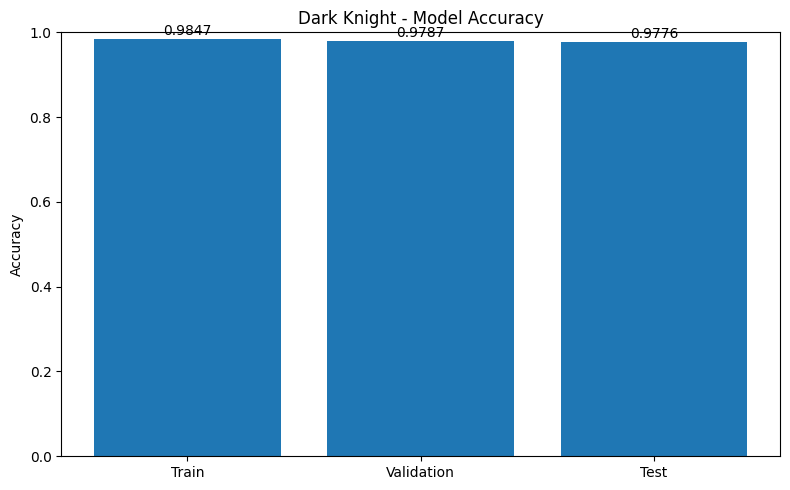

<Figure size 700x600 with 0 Axes>

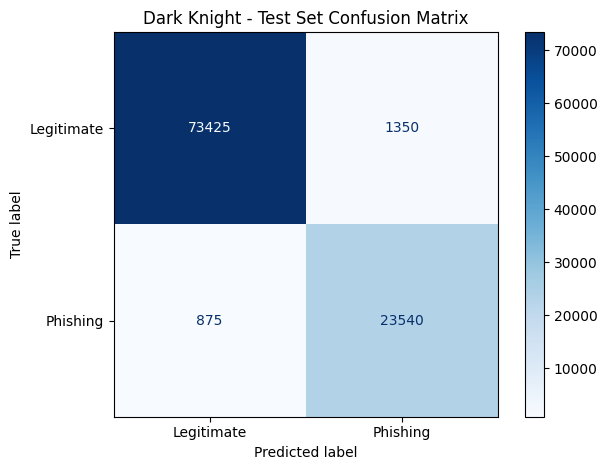

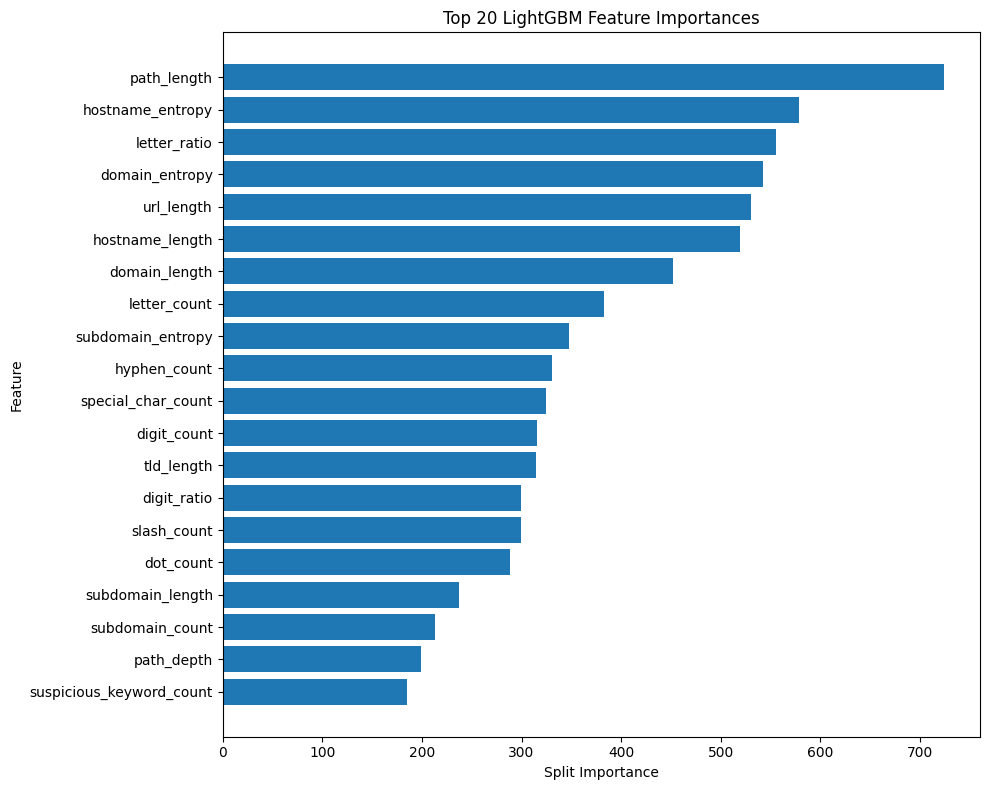

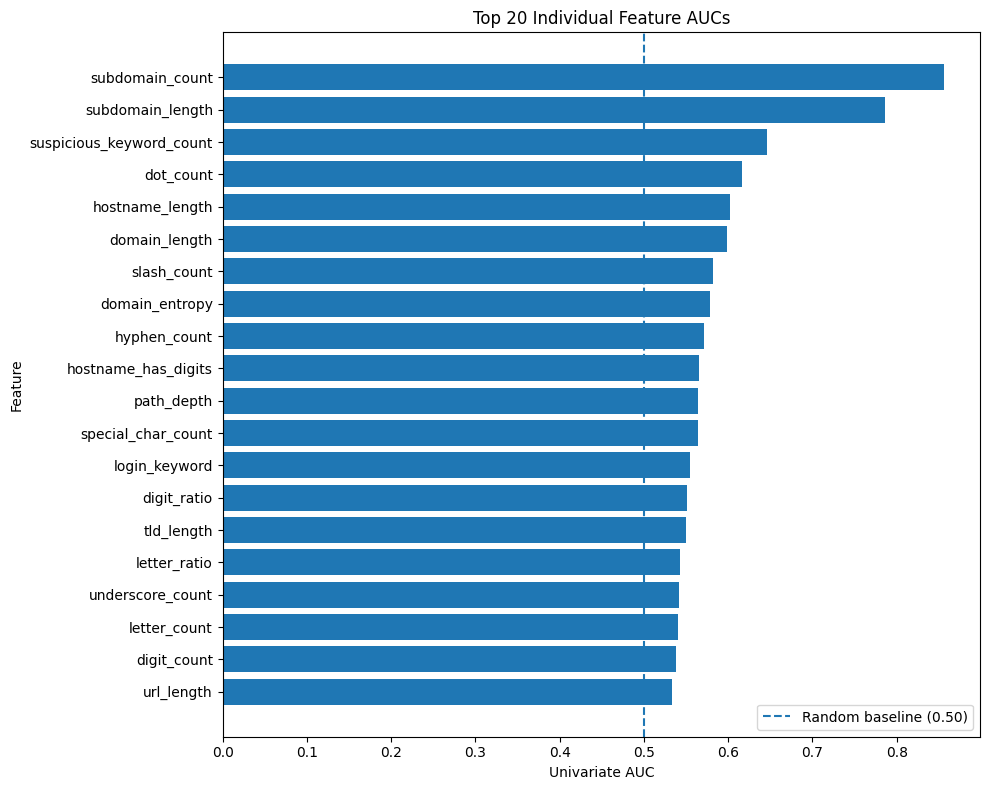

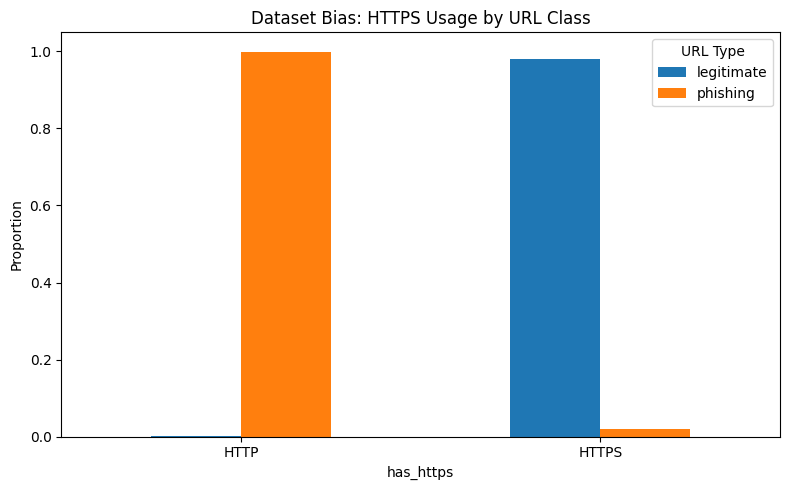

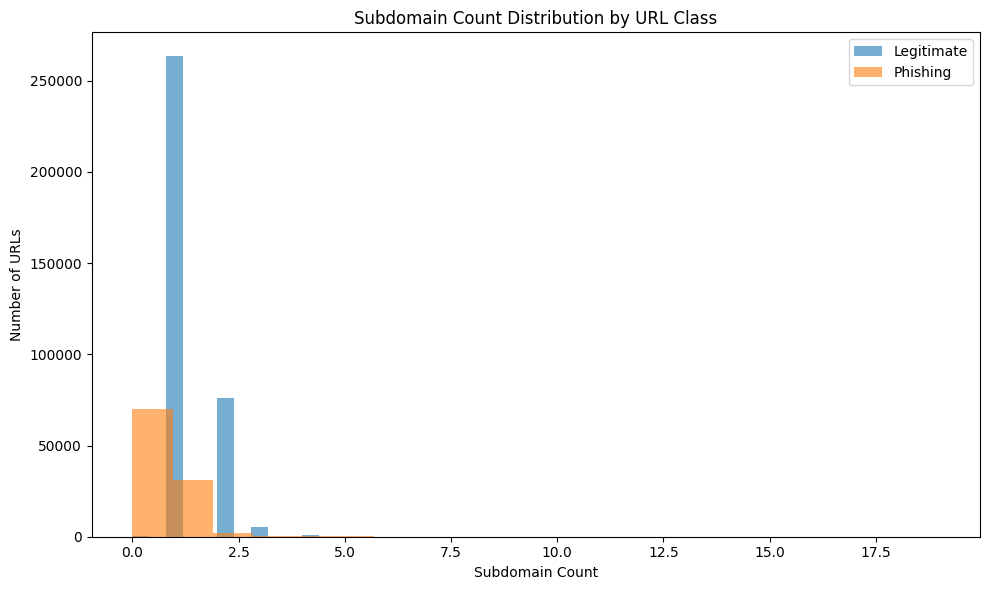

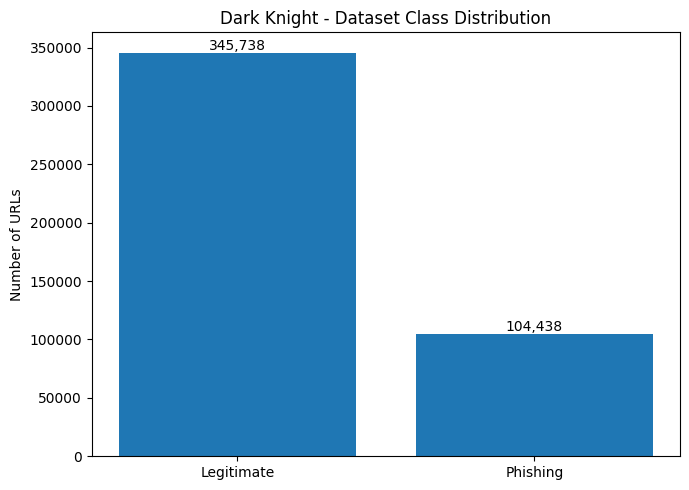

VISUALIZATION COMPLETE
Train Accuracy      : 0.9847
Validation Accuracy : 0.9787
Test Accuracy       : 0.9776


In [65]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

# 1. TRAIN vs VALIDATION vs TEST ACCURACY

train_accuracy = accuracy_score(y_train, train_pred)
val_accuracy = accuracy_score(y_val, val_pred)
test_accuracy = accuracy_score(y_test, test_pred)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    ["Train", "Validation", "Test"],
    [train_accuracy, val_accuracy, test_accuracy]
)

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Dark Knight - Model Accuracy")

for bar, value in zip(bars, [train_accuracy, val_accuracy, test_accuracy]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()
plt.show()


# 2. CONFUSION MATRIX
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Phishing"]
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Dark Knight - Test Set Confusion Matrix")
plt.tight_layout()
plt.show()


# 3. TOP LIGHTGBM FEATURE IMPORTANCE

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
).head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance["feature"][::-1],
    feature_importance["importance"][::-1]
)

plt.xlabel("Split Importance")
plt.ylabel("Feature")
plt.title("Top 20 LightGBM Feature Importances")

plt.tight_layout()
plt.show()


# 4. UNIVARIATE FEATURE AUC


if "auc_results" not in globals():

    auc_data = []
    y_binary = (dataset["type"] == "phishing").astype(int)

    for feature in X.columns:

        try:
            auc = roc_auc_score(
                y_binary,
                dataset[feature]
            )

            # AUC below 0.5 can still be predictive in the
            # opposite direction, so use max(AUC, 1-AUC)
            auc = max(auc, 1 - auc)

            auc_data.append({
                "feature": feature,
                "auc": auc
            })

        except Exception:
            pass

    auc_results = pd.DataFrame(auc_data)

auc_plot = auc_results.sort_values(
    "auc",
    ascending=False
).head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    auc_plot["feature"][::-1],
    auc_plot["auc"][::-1]
)

plt.axvline(
    0.5,
    linestyle="--",
    label="Random baseline (0.50)"
)

plt.xlabel("Univariate AUC")
plt.ylabel("Feature")
plt.title("Top 20 Individual Feature AUCs")

plt.legend()
plt.tight_layout()
plt.show()


# 5. has_https DATASET BIAS

https_distribution = pd.crosstab(
    dataset["has_https"],
    dataset["type"],
    normalize="index"
)

https_distribution.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("has_https")
plt.ylabel("Proportion")
plt.title("Dataset Bias: HTTPS Usage by URL Class")
plt.xticks(
    [0, 1],
    ["HTTP", "HTTPS"],
    rotation=0
)

plt.legend(title="URL Type")
plt.tight_layout()
plt.show()


# 6. SUBDOMAIN COUNT BY CLASS

plt.figure(figsize=(10, 6))

plt.hist(
    dataset.loc[
        dataset["type"] == "legitimate",
        "subdomain_count"
    ],
    bins=20,
    alpha=0.6,
    label="Legitimate"
)

plt.hist(
    dataset.loc[
        dataset["type"] == "phishing",
        "subdomain_count"
    ],
    bins=20,
    alpha=0.6,
    label="Phishing"
)

plt.xlabel("Subdomain Count")
plt.ylabel("Number of URLs")
plt.title("Subdomain Count Distribution by URL Class")
plt.legend()

plt.tight_layout()
plt.show()


# 7. DATASET CLASS DISTRIBUTION

class_counts = dataset["type"].value_counts()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["Legitimate", "Phishing"],
    [
        class_counts.get("legitimate", 0),
        class_counts.get("phishing", 0)
    ]
)

plt.ylabel("Number of URLs")
plt.title("Dark Knight - Dataset Class Distribution")

for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{int(value):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


print("============================================================")
print("VISUALIZATION COMPLETE")
print("============================================================")
print(f"Train Accuracy      : {train_accuracy:.4f}")
print(f"Validation Accuracy : {val_accuracy:.4f}")
print(f"Test Accuracy       : {test_accuracy:.4f}")
print("============================================================")